#  Project 13 — PCA + K-Means (Dimensionality Reduction + Clustering)

## This project combines:

* ✅ PCA (Reduce Features)
* ✅ K-Means (Create Clusters)

This is a very common workflow in real-world Machine Learning.

🎯 Problem Statement

We have 2 features:

* Hours
* Practice

We'll:

1. Scale the data
2. Apply PCA
3. Reduce to 1 component
4. Apply K-Means
5. Find clusters

In [19]:
# Self Practice

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

df = pd.DataFrame({
    "Hours" : [1,2,3,4,5,6,7,8,9,10],
    "Practice" : [2,4,6,8,10,12,14,16,18,20]
})

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
print(f"Scaled Data : {scaled_data}")

pca = PCA(n_components = 1)
pca_data = pca.fit_transform(scaled_data)
print(f"\nPCA Data : {pca_data}")

kmeans = KMeans(n_clusters = 2, random_state = 42)
kmeans.fit_transform(pca_data)
df['Cluster'] = kmeans.labels_
print(f"\nCluster : {df["Cluster"]}")

print(f"\nCluster Centers : {kmeans.cluster_centers_}")

print(f"\n{df}")

Scaled Data : [[-1.5666989  -1.5666989 ]
 [-1.21854359 -1.21854359]
 [-0.87038828 -0.87038828]
 [-0.52223297 -0.52223297]
 [-0.17407766 -0.17407766]
 [ 0.17407766  0.17407766]
 [ 0.52223297  0.52223297]
 [ 0.87038828  0.87038828]
 [ 1.21854359  1.21854359]
 [ 1.5666989   1.5666989 ]]

PCA Data : [[-2.21564684]
 [-1.72328087]
 [-1.23091491]
 [-0.73854895]
 [-0.24618298]
 [ 0.24618298]
 [ 0.73854895]
 [ 1.23091491]
 [ 1.72328087]
 [ 2.21564684]]

Cluster : 0    0
1    0
2    0
3    0
4    0
5    0
6    1
7    1
8    1
9    1
Name: Cluster, dtype: int32

Cluster Centers : [[-0.98473193]
 [ 1.47709789]]

   Hours  Practice  Cluster
0      1         2        0
1      2         4        0
2      3         6        0
3      4         8        0
4      5        10        0
5      6        12        0
6      7        14        1
7      8        16        1
8      9        18        1
9     10        20        1


C:\DevTools\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [20]:
 # Step 1: Import Libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [21]:
# Step 2: Create Dataset

df = pd.DataFrame({
    "Hours":[1,2,3,4,5,6,7,8,9,10],
    "Practice":[2,4,6,8,10,12,14,16,18,20]
})

print(df)

   Hours  Practice
0      1         2
1      2         4
2      3         6
3      4         8
4      5        10
5      6        12
6      7        14
7      8        16
8      9        18
9     10        20


In [22]:
# Step 3: Scale Data

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)


In [23]:
# Step 4: Apply PCA

pca = PCA(n_components=1)

pca_data = pca.fit_transform(scaled_data)

print("PCA Data:\n", pca_data)

PCA Data:
 [[-2.21564684]
 [-1.72328087]
 [-1.23091491]
 [-0.73854895]
 [-0.24618298]
 [ 0.24618298]
 [ 0.73854895]
 [ 1.23091491]
 [ 1.72328087]
 [ 2.21564684]]


In [24]:
# Step 5: Apply K-Means

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

kmeans.fit(pca_data)

C:\DevTools\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=2, random_state=42)

In [25]:
 # Step 6: Add Cluster Labels

df["Cluster"] = kmeans.labels_

print(df)

   Hours  Practice  Cluster
0      1         2        0
1      2         4        0
2      3         6        0
3      4         8        0
4      5        10        0
5      6        12        0
6      7        14        1
7      8        16        1
8      9        18        1
9     10        20        1


In [26]:
# Step 7: Cluster Centers

print(
    "Cluster Centers:\n",
    kmeans.cluster_centers_
)

Cluster Centers:
 [[-0.98473193]
 [ 1.47709789]]


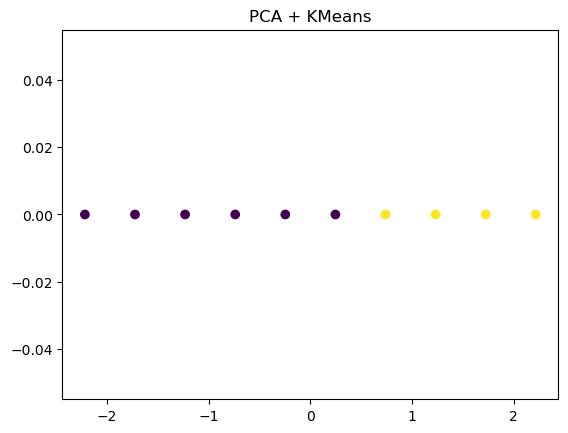

In [27]:
 # Step 8: Visualization

plt.scatter(
    pca_data,
    [0]*len(pca_data),
    c=df["Cluster"]
)

plt.title("PCA + KMeans")
plt.show()

## Why PCA + K-Means?

**Without PCA:**

* Many Features
* ↓
* K-Means becomes slower

**With PCA:**

* Reduce Features
* ↓
* Less Noise
* ↓
* Faster Clustering

##  Interview Questions
After running the code, answer:

1. Why do we apply PCA before K-Means?
2. What is the benefit of reducing dimensions?
3. Does PCA perform clustering?
4. Which algorithm creates the clusters: PCA or K-Means?
5. If PCA reduces 10 features to 2, what information might be lost?


In [28]:
# Ans 1 :
# PCA reduces the number of features, removes redundant information, and helps K-Means run faster and more efficiently.

# Ans 2 : 
# • Faster computation
# • Less memory usage
# • Reduced noise
# • Easier visualization

# Ans 3 :
# No
# PCA only reduces dimensions.
# It does not create clusters.

# Ans 4 :
# PCA → Feature Reduction
# K-Means → Clustering

# Ans 5 :
# Some variance (information) from the original features may be lost.
# The amount lost depends on the explained_variance_ratio_.

# Example:

# explained_variance_ratio_ = 0.95
# means:

# 95% information retained
# 5% information lost


